# ETF & Stock Database: SMA Crossover Strategy vs Buy & Hold

**Goal:** Download 10 years of daily prices for 20 symbols (10 ETFs and 10 large companies such as Nvidia and Apple) with our own code, clean the data, and compare a simple moving average (SMA) strategy with Buy & Hold.

**Steps:** download → clean → period returns → strategy → backtest → results

**How to read this notebook**
The project code lives in four files in the `scripts/` folder: `config.py`, `fetch_data.py`, `clean_data.py` and `backtest.py`. The notebook imports the functions from these files. In every section we first show the **code** of the function (with its comments), then we run it and look at the result.

There is only one copy of each function: the functions shown here are the same ones that run with `python run_all.py`.

## 0. Setup

We load the libraries and the files in `scripts/`. `show_code` is a small helper that prints the source code of a function.

In [1]:
import inspect
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

# Add the scripts/ folder to the Python path (the notebook is one folder below the project root)
sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import config
import fetch_data
import clean_data
import backtest


def show_code(obj):
    # Shows the source code of a function (or a file) as a code block
    return Markdown(f"```python\n{inspect.getsource(obj)}\n```")

In [2]:
# Chart settings: plain look, light grid lines
plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
})

# Colors used in the charts
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"  # lines
GREEN, RED = "#0ca30c", "#d03b3b"                     # positive / negative

# Show numbers in tables with two decimals
pd.options.display.float_format = "{:,.2f}".format

## 1. Settings

The symbols, the period and the strategy settings are all in one file (`scripts/config.py`). To change a value we only edit this file.

In [3]:
show_code(config)

```python
"""All project settings in one place. The scripts and the notebook read them from here."""
from pathlib import Path

# The symbols we study (10 ETFs and 10 large companies), each with a short name and a group
SYMBOLS = {
    "SPY": {"name": "S&P 500", "group": "US index ETFs"},
    "QQQ": {"name": "Nasdaq 100", "group": "US index ETFs"},
    "DIA": {"name": "Dow Jones", "group": "US index ETFs"},
    "IWM": {"name": "Russell 2000", "group": "US index ETFs"},
    "EFA": {"name": "Developed markets (ex-US)", "group": "International ETFs"},
    "EEM": {"name": "Emerging markets", "group": "International ETFs"},
    "TUR": {"name": "Turkey (MSCI Turkey)", "group": "International ETFs"},
    "GLD": {"name": "Gold", "group": "Commodity ETFs"},
    "SLV": {"name": "Silver", "group": "Commodity ETFs"},
    "TLT": {"name": "Long-term US Treasury bonds", "group": "Bond ETFs"},
    "NVDA": {"name": "Nvidia", "group": "Companies"},
    "AAPL": {"name": "Apple", "group": "Companies"},
    "MSFT": {"name": "Microsoft", "group": "Companies"},
    "GOOGL": {"name": "Alphabet (Google)", "group": "Companies"},
    "AMZN": {"name": "Amazon", "group": "Companies"},
    "META": {"name": "Meta Platforms", "group": "Companies"},
    "TSLA": {"name": "Tesla", "group": "Companies"},
    "JPM": {"name": "JPMorgan Chase", "group": "Companies"},
    "XOM": {"name": "Exxon Mobil", "group": "Companies"},
    "KO": {"name": "Coca-Cola", "group": "Companies"},
}

YEARS = 10                 # how many years of data to download

# Strategy settings
SMA_SHORT = 50             # short moving average (days)
SMA_LONG = 200             # long moving average (days)
COMMISSION = 0.001         # 0.1% commission on every trade
INITIAL_CAPITAL = 10_000   # starting capital ($)
TRADING_DAYS = 252         # trading days in a year (turns daily values into yearly values)

# Download settings
REQUEST_TIMEOUT = 30       # longest wait for one request (seconds)
MAX_TRIES = 3              # how many times one request is tried
SLEEP_SECONDS = 2          # pause between requests (seconds)

# Folders
ROOT = Path(__file__).resolve().parent.parent
RAW_DIR = ROOT / "data" / "raw"          # downloaded raw data
CLEAN_DIR = ROOT / "data" / "clean"      # cleaned data
OUTPUT_DIR = ROOT / "public" / "data"    # JSON files read by the dashboard

```

## 2. Download the data

**Source:** Yahoo Finance's public chart address

`https://query1.finance.yahoo.com/v8/finance/chart/<SYMBOL>?period1=<start>&period2=<end>&interval=1d`

- No API key, no account and no ready-made data library (such as yfinance). The request is sent with `requests` and the answer is parsed with our own code.
- Yahoo rejects requests whose `User-Agent` header is `python-requests` (error 429), so we send a plain browser-style header (`Mozilla/5.0`).
- **Backup source:** Stooq's CSV download address. When this homework was prepared, Stooq asked for a browser check (JavaScript) and did not return data to a plain request. The code notices this and prints a warning. That is why Yahoo is the main source.

### 2.1 Period and request

First, two small functions: one returns the period to download, the other sends the request (and tries again if there is an error).

In [4]:
show_code(fetch_data.date_range)

```python
def date_range():
    """Returns the period to download: the last YEARS years.

    The end is the start of today (00:00 UTC). This way the unfinished
    trading day is never included, only completed days.
    """
    end = pd.Timestamp.now(tz="UTC").normalize()
    start = end - pd.DateOffset(years=config.YEARS)
    return start, end

```

In [5]:
show_code(fetch_data.get_with_retry)

```python
def get_with_retry(url, params):
    """Sends a GET request; on an error it waits a little and tries again."""
    for attempt in range(1, config.MAX_TRIES + 1):
        try:
            response = requests.get(
                url, params=params, headers=HEADERS, timeout=config.REQUEST_TIMEOUT
            )
            response.raise_for_status()  # treat 4xx / 5xx answers as errors
            return response
        except requests.RequestException as error:
            print(f"    attempt {attempt}/{config.MAX_TRIES} failed: {error}")
            if attempt == config.MAX_TRIES:
                raise
            time.sleep(config.SLEEP_SECONDS * attempt)  # wait a bit longer each time

```

What does Yahoo's answer look like? Let us download the raw answer for one symbol and look at its structure:

In [6]:
start, end = fetch_data.date_range()
print("Period:", start.date(), "to", end.date())

# Send the request for SPY and look inside the JSON answer
params = {"period1": int(start.timestamp()), "period2": int(end.timestamp()), "interval": "1d"}
response = fetch_data.get_with_retry(fetch_data.YAHOO_URL.format(symbol="SPY"), params)
result = response.json()["chart"]["result"][0]

print("Parts of the answer:", list(result.keys()))
print("Price fields       :", list(result["indicators"]["quote"][0].keys()))
print("Number of rows     :", len(result["timestamp"]))
print("First 3 timestamps :", result["timestamp"][:3])
print("First 3 closes     :", result["indicators"]["quote"][0]["close"][:3])

Period: 2016-10-05 to 2026-10-05


Parts of the answer: ['meta', 'timestamp', 'indicators']
Price fields       : ['low', 'open', 'high', 'volume', 'close']
Number of rows     : 2512
First 3 timestamps : [1475674200, 1475760600, 1475847000]
First 3 closes     : [215.6300048828125, 215.77999877929688, 215.0399932861328]


The dates come as Unix seconds and the prices come as separate lists. We need to put them into one table (a DataFrame).

### 2.2 Turning the answer into a DataFrame

In [7]:
show_code(fetch_data.fetch_yahoo)

```python
def fetch_yahoo(symbol, start, end):
    """Downloads the daily data of one symbol from Yahoo Finance as a DataFrame."""
    params = {
        "period1": int(start.timestamp()),  # start (Unix seconds)
        "period2": int(end.timestamp()),    # end (Unix seconds)
        "interval": "1d",                   # daily data
    }
    response = get_with_retry(YAHOO_URL.format(symbol=symbol), params)
    result = response.json()["chart"]["result"][0]

    # The answer holds the dates and the prices as separate lists of the same length.
    quote = result["indicators"]["quote"][0]
    df = pd.DataFrame({
        "Date": result["timestamp"],
        "Open": quote["open"],
        "High": quote["high"],
        "Low": quote["low"],
        "Close": quote["close"],
        "Adj Close": result["indicators"]["adjclose"][0]["adjclose"],
        "Volume": quote["volume"],
    })

    # Dates arrive as Unix seconds (the moment the session opens). We convert
    # them to the time zone of the exchange and keep only the day.
    timezone = result["meta"]["exchangeTimezoneName"]
    dates = pd.to_datetime(df["Date"], unit="s", utc=True).dt.tz_convert(timezone)
    df["Date"] = dates.dt.strftime("%Y-%m-%d")
    return df

```

In [8]:
# Run the function for SPY: first and last rows
raw_spy = fetch_data.fetch_yahoo("SPY", start, end)
display(raw_spy.head(3), raw_spy.tail(3))

,Date,Open,High,Low,Close,Adj Close,Volume
0,2016-10-05,215.41,216.13,215.33,215.63,184.15,72816000
1,2016-10-06,215.37,216.04,214.74,215.78,184.28,62927400
2,2016-10-07,216.10,216.30,214.19,215.04,183.64,89788300


,Date,Open,High,Low,Close,Adj Close,Volume
2509,2026-09-30,766.45,769.41,762.18,762.63,762.63,62110000
2510,2026-10-01,764.36,765.65,758.79,763.99,763.99,47708100
2511,2026-10-02,770.58,772.65,767.15,769.64,769.64,46306400


### 2.3 Backup source and errors

`fetch_symbol` tries Yahoo first and then Stooq. If both fail it does not raise an error: it prints a warning and returns `None`. This way the script does not stop when one symbol is missing.

In [9]:
show_code(fetch_data.fetch_stooq)

```python
def fetch_stooq(symbol, start, end):
    """Backup source: Stooq's CSV download address (it has no adjusted close column)."""
    params = {
        "s": f"{symbol.lower()}.us",     # US symbols end with ".us" on Stooq
        "d1": start.strftime("%Y%m%d"),  # start
        "d2": (end - pd.Timedelta(days=1)).strftime("%Y%m%d"),  # end (yesterday included)
        "i": "d",                        # daily data
    }
    response = get_with_retry(STOOQ_URL, params)
    # Stooq can also answer with a verification or error page; check that it is a CSV.
    if not response.text.startswith("Date,"):
        raise ValueError("Stooq returned a page instead of a CSV file")
    # read_csv expects a file; StringIO lets it read the downloaded text like a file.
    return pd.read_csv(io.StringIO(response.text))

```

In [10]:
show_code(fetch_data.fetch_symbol)

```python
def fetch_symbol(symbol):
    """Tries Yahoo first, then Stooq. Returns None if both fail."""
    start, end = date_range()
    for source, fetch in [("Yahoo Finance", fetch_yahoo), ("Stooq", fetch_stooq)]:
        try:
            df = fetch(symbol, start, end)
            print(f"  {symbol}: {len(df)} rows downloaded ({source})")
            return df
        except Exception as error:  # network error, unexpected answer... do not stop the script
            print(f"  WARNING: could not get {symbol} from {source}: {error}")
    return None

```

In [11]:
# Test: ask for a symbol that does not exist. The script must not crash; it must return None.
result = fetch_data.fetch_symbol("NO_SUCH_SYMBOL")
print("Returned value:", result)

    attempt 1/3 failed: 404 Client Error: Not Found for url: https://query1.finance.yahoo.com/v8/finance/chart/NO_SUCH_SYMBOL?period1=1475625600&period2=1791158400&interval=1d


    attempt 2/3 failed: 404 Client Error: Not Found for url: https://query1.finance.yahoo.com/v8/finance/chart/NO_SUCH_SYMBOL?period1=1475625600&period2=1791158400&interval=1d


    attempt 3/3 failed: 404 Client Error: Not Found for url: https://query1.finance.yahoo.com/v8/finance/chart/NO_SUCH_SYMBOL?period1=1475625600&period2=1791158400&interval=1d


Returned value: None


### 2.4 Download and save every symbol

`main` downloads every symbol in `config.SYMBOLS` and saves it as `data/raw/<SYMBOL>.csv`. There is a short pause between the requests.

In [12]:
show_code(fetch_data.main)

```python
def main():
    """Downloads every symbol. Returns the list of symbols that could not be downloaded."""
    config.RAW_DIR.mkdir(parents=True, exist_ok=True)
    failed = []
    for symbol in config.SYMBOLS:
        df = fetch_symbol(symbol)
        if df is None:
            failed.append(symbol)  # skip this symbol and continue with the others
        else:
            df.to_csv(config.RAW_DIR / f"{symbol}.csv", index=False)
        time.sleep(config.SLEEP_SECONDS)  # short pause so we do not overload the server
    return failed

```

In [13]:
failed = fetch_data.main()
print("Symbols that could not be downloaded:", failed if failed else "none")

  SPY: 2512 rows downloaded (Yahoo Finance)


  QQQ: 2512 rows downloaded (Yahoo Finance)


  DIA: 2512 rows downloaded (Yahoo Finance)


  IWM: 2512 rows downloaded (Yahoo Finance)


  EFA: 2512 rows downloaded (Yahoo Finance)


...

  TSLA: 2512 rows downloaded (Yahoo Finance)


  JPM: 2512 rows downloaded (Yahoo Finance)


  XOM: 2512 rows downloaded (Yahoo Finance)


  KO: 2512 rows downloaded (Yahoo Finance)


Symbols that could not be downloaded: none


## 3. Clean the data

Before the analysis we check and fix the raw data. The `clean` function does these steps:

1. Simplifies the column names.
2. Converts the date to datetime and makes it the index (rows with an unreadable date are dropped).
3. Drops repeated days, then sorts the rows from old to new.
4. Uses the close if there is no adjusted close column.
5. Converts every column to numbers.
6. Treats zero or negative prices as invalid.
7. Fills missing prices with the last known price (forward-fill).

In [14]:
show_code(clean_data.clean)

```python
def clean(raw):
    """Cleans a raw DataFrame. Returns (clean DataFrame, quality summary)."""
    df = raw.copy()

    # 1) Simplify the column names: "Adj Close" -> "adj_close"
    df.columns = [name.strip().lower().replace(" ", "_") for name in df.columns]

    # 2) Convert the date to datetime and make it the index (rows with an unreadable date are dropped)
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"]).set_index("date")

    # 3) Drop repeated days (keep the last one in the file), then sort from old to new
    is_duplicate = df.index.duplicated(keep="last")
    df = df[~is_duplicate].sort_index()

    # 4) If there is no adjusted close column (for example Stooq), use the close
    if "adj_close" not in df.columns:
        df["adj_close"] = df["close"]

    # 5) Type conversion: every column becomes a number; values that are not numbers become NaN (missing)
    df = df[PRICE_COLUMNS + ["volume"]].apply(pd.to_numeric, errors="coerce").astype(float)
    missing = int(df.isna().sum().sum())

    # 6) A price cannot be zero or negative: count such values, then treat them as missing
    invalid = int((df[PRICE_COLUMNS] <= 0).sum().sum())
    df[PRICE_COLUMNS] = df[PRICE_COLUMNS].where(df[PRICE_COLUMNS] > 0)

    # 7) Fill the missing values.
    # Prices use forward-fill: a missing price gets the last known price.
    # This only uses information from the past. Back-fill or interpolation
    # would bring a later price into an earlier day and mislead the backtest.
    df[PRICE_COLUMNS] = df[PRICE_COLUMNS].ffill()
    df["volume"] = df["volume"].fillna(0)  # unknown volume becomes 0 (volume is not used in the analysis)
    df = df.dropna()                       # rows at the very start that could not be filled
    df["volume"] = df["volume"].astype("int64")

    summary = {
        "rows": len(df),
        "start": df.index[0].strftime("%Y-%m-%d"),
        "end": df.index[-1].strftime("%Y-%m-%d"),
        "missing": missing,
        "duplicates": int(is_duplicate.sum()),
        "invalid_prices": invalid,
    }
    return df, summary

```

### 3.1 A small example

The real data may have no problems. To see that the rules work, let us clean a small table with errors that we put in on purpose: unsorted dates, a repeated day, missing values, a cell with letters and a negative price.

In [15]:
dirty = pd.DataFrame({
    "Date":      ["2024-01-05", "2024-01-03", "2024-01-03", "2024-01-04", "2024-01-08"],
    "Open":      [10.4,         10.0,         10.1,         "abc",        10.6],
    "High":      [10.8,         10.3,         10.4,         10.5,         11.0],
    "Low":       [10.2,         9.8,          9.9,          10.0,         10.5],
    "Close":     [10.5,         10.2,         10.3,         -5,           10.8],
    "Adj Close": [10.4,         10.1,         10.2,         None,         None],
    "Volume":    [1000,         900,          950,          None,         1200],
})
display(dirty)

cleaned, summary = clean_data.clean(dirty)
display(cleaned)
print("Quality summary:", summary)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2024-01-05,10.40,10.80,10.20,10.50,10.40,"1,000.00"
1,2024-01-03,10.00,10.30,9.80,10.20,10.10,900.00
2,2024-01-03,10.10,10.40,9.90,10.30,10.20,950.00
3,2024-01-04,abc,10.50,10.00,-5.00,NaN,NaN
4,2024-01-08,10.60,11.00,10.50,10.80,NaN,"1,200.00"


,open,high,low,close,adj_close,volume
date,,,,,,
2024-01-03,10.10,10.40,9.90,10.30,10.20,950
2024-01-04,10.10,10.50,10.00,10.30,10.20,0
2024-01-05,10.40,10.80,10.20,10.50,10.40,1000
2024-01-08,10.60,11.00,10.50,10.80,10.40,1200


Quality summary: {'rows': 4, 'start': '2024-01-03', 'end': '2024-01-08', 'missing': 4, 'duplicates': 1, 'invalid_prices': 1}


Result: the dates are sorted, the last of the two January 3 rows is kept, the `abc` and `-5` values on January 4 and the missing adjusted closes are filled with the previous day's price, and the missing volume becomes 0.

### 3.2 Real data

Now we use the same function on the SPY data that we downloaded:

In [16]:
clean_spy, summary = clean_data.clean(pd.read_csv(config.RAW_DIR / "SPY.csv"))
print("Quality summary:", summary)
print()
clean_spy.info()
clean_spy.tail(3)

Quality summary: {'rows': 2512, 'start': '2016-10-05', 'end': '2026-10-02', 'missing': 0, 'duplicates': 0, 'invalid_prices': 0}

<class 'pandas.DataFrame'>
DatetimeIndex: 2512 entries, 2016-10-05 to 2026-10-02
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   open       2512 non-null   float64
 1   high       2512 non-null   float64
 2   low        2512 non-null   float64
 3   close      2512 non-null   float64
 4   adj_close  2512 non-null   float64
 5   volume     2512 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 137.4 KB


,open,high,low,close,adj_close,volume
date,,,,,,
2026-09-30,766.45,769.41,762.18,762.63,762.63,62110000
2026-10-01,764.36,765.65,758.79,763.99,763.99,47708100
2026-10-02,770.58,772.65,767.15,769.64,769.64,46306400


`main` cleans every symbol, saves it as `data/clean/<SYMBOL>.csv` and prints the quality summary for each one:

In [17]:
show_code(clean_data.main)

```python
def main():
    """Cleans and saves every symbol that has raw data."""
    config.CLEAN_DIR.mkdir(parents=True, exist_ok=True)
    for symbol in config.SYMBOLS:
        raw_path = config.RAW_DIR / f"{symbol}.csv"
        if not raw_path.exists():
            print(f"  WARNING: no raw data for {symbol}, skipping")
            continue

        df, summary = clean(pd.read_csv(raw_path))
        df.to_csv(config.CLEAN_DIR / f"{symbol}.csv")
        print(
            f"  {symbol}: {summary['rows']} rows, {summary['start']} to {summary['end']}, "
            f"missing values: {summary['missing']}, repeated days: {summary['duplicates']}, "
            f"invalid prices: {summary['invalid_prices']}"
        )

```

In [18]:
clean_data.main()

  SPY: 2512 rows, 2016-10-05 to 2026-10-02, missing values: 0, repeated days: 0, invalid prices: 0
  QQQ: 2512 rows, 2016-10-05 to 2026-10-02, missing values: 0, repeated days: 0, invalid prices: 0
  DIA: 2512 rows, 2016-10-05 to 2026-10-02, missing values: 0, repeated days: 0, invalid prices: 0
  IWM: 2512 rows, 2016-10-05 to 2026-10-02, missing values: 0, repeated days: 0, invalid prices: 0
  EFA: 2512 rows, 2016-10-05 to 2026-10-02, missing values: 0, repeated days: 0, invalid prices: 0
  EEM: 2512 rows, 2016-10-05 to 2026-10-02, missing values: 0, repeated days: 0, invalid prices: 0
  TUR: 2512 rows, 2016-10-05 to 2026-10-02, missing values: 0, repeated days: 0, invalid prices: 0
  GLD: 2512 rows, 2016-10-05 to 2026-10-02, missing values: 0, repeated days: 0, invalid prices: 0
  SLV: 2512 rows, 2016-10-05 to 2026-10-02, missing values: 0, repeated days: 0, invalid prices: 0
  TLT: 2512 rows, 2016-10-05 to 2026-10-02, missing values: 0, repeated days: 0, invalid prices: 0
  NVDA: 25

  TSLA: 2512 rows, 2016-10-05 to 2026-10-02, missing values: 0, repeated days: 0, invalid prices: 0
  JPM: 2512 rows, 2016-10-05 to 2026-10-02, missing values: 0, repeated days: 0, invalid prices: 0
  XOM: 2512 rows, 2016-10-05 to 2026-10-02, missing values: 0, repeated days: 0, invalid prices: 0


  KO: 2512 rows, 2016-10-05 to 2026-10-02, missing values: 0, repeated days: 0, invalid prices: 0


## 4. Period returns

From here on we work with the clean data. As the price we use the **adjusted close**, because it includes the effect of dividends and splits.

The symbol to study is chosen in the next cell. To look at another symbol, change `symbol` and run the following cells again.

In [19]:
symbol = "SPY"
price = backtest.load_clean(symbol)["adj_close"]
price.tail(3)

date
2026-09-30   762.63
2026-10-01   763.99
2026-10-02   769.64
Name: adj_close, dtype: float64

`period_returns` groups the price series by the chosen period (`resample`) and computes the percent change between period-end prices:

In [20]:
show_code(backtest.period_returns)

```python
def period_returns(price, freq):
    """Computes percent returns per period from a price (or portfolio value) series."""
    if freq == "D":  # daily: change from the previous trading day
        return price.pct_change().dropna() * 100

    period_end = price.resample(freq).last().dropna()  # last value of each period
    returns = period_end.pct_change()
    # The first period has no period before it; we measure it from the first value in the data.
    returns.iloc[0] = period_end.iloc[0] / price.iloc[0] - 1
    return returns * 100

```

In [21]:
# Compute the returns for the four periods; show the last 3 values of each
for name, (freq, date_format) in backtest.PERIODS.items():
    returns = backtest.period_returns(price, freq)
    print(f"{name:8s} {len(returns):5d} periods | last three values (%):", returns.tail(3).round(2).tolist())

daily     2511 periods | last three values (%): [-0.21, 0.18, 0.74]
weekly     522 periods | last three values (%): [-0.09, 1.27, -0.22]
monthly    121 periods | last three values (%): [2.68, -0.33, 0.92]
yearly      11 periods | last three values (%): [24.89, 17.72, 13.75]


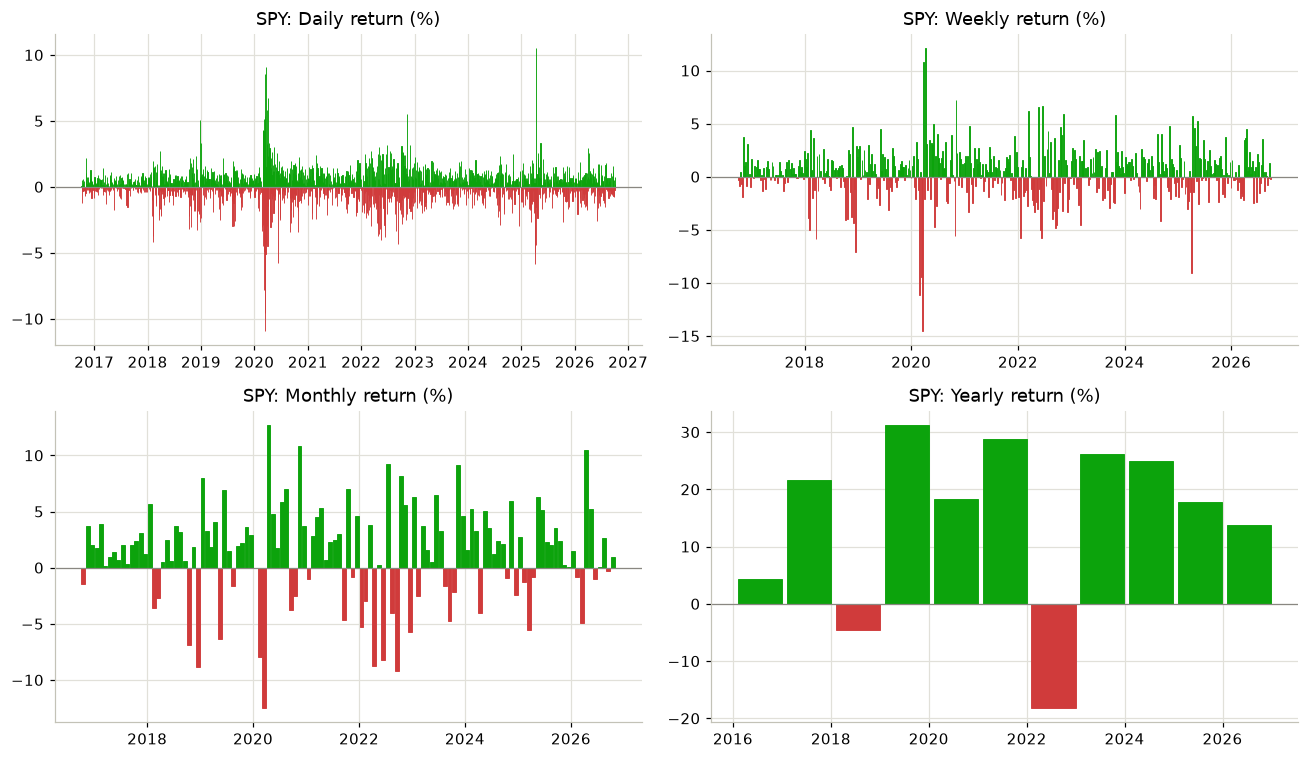

In [22]:
# Draw the four periods as bar charts: positive green, negative red.
# Each bar covers its period from start to end (the width is in days).
titles = {"daily": "Daily", "weekly": "Weekly", "monthly": "Monthly", "yearly": "Yearly"}
days = {"daily": 1, "weekly": 7, "monthly": 30, "yearly": 365}

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (name, (freq, date_format)) in zip(axes.flat, backtest.PERIODS.items()):
    returns = backtest.period_returns(price, freq)
    colors = [GREEN if value >= 0 else RED for value in returns]
    # edgecolor: so that the very thin bars of the daily chart are also visible
    ax.bar(returns.index, returns, width=-0.9 * days[name], align="edge",
           color=colors, edgecolor=colors, linewidth=0.6)
    ax.axhline(0, color="#898781", linewidth=0.8)
    ax.set_title(f"{symbol}: {titles[name]} return (%)")
fig.tight_layout()
plt.show()

Let us put the yearly returns of all symbols side by side. The first year (the data starts in the middle of the year) and the current year are **partial** years.

In [23]:
yearly = pd.DataFrame({
    s: backtest.period_returns(backtest.load_clean(s)["adj_close"], "YE") for s in config.SYMBOLS
})
yearly.index = yearly.index.year
yearly.index.name = "year"
yearly

,SPY,QQQ,DIA,IWM,EFA,EEM,TUR,GLD,SLV,TLT,NVDA,AAPL,MSFT,GOOGL,AMZN,META,TSLA,JPM,XOM,KO
year,,,,,,,,,,,,,,,,,,,,
2016,4.27,0.03,8.78,9.24,-1.47,-6.40,-14.03,-9.25,-10.33,-10.90,56.68,2.98,8.54,-1.10,-11.19,-10.45,2.51,27.48,4.67,0.00
2017,21.71,32.66,28.08,14.58,25.08,37.26,37.58,12.81,5.82,9.18,81.99,48.46,40.73,32.93,55.96,53.38,45.70,26.76,-3.81,14.38
2018,-4.57,-0.13,-3.74,-11.12,-13.82,-15.31,-41.46,-1.94,-9.19,-1.61,-30.82,-5.39,20.80,-0.80,28.43,-25.71,6.89,-6.62,-15.09,6.77
2019,31.22,38.96,25.03,25.39,22.04,18.22,14.49,17.86,14.88,14.12,76.94,88.96,57.56,28.18,23.03,56.57,25.70,47.26,7.23,20.60
2020,18.33,48.41,9.59,20.03,7.60,17.02,-1.19,24.81,47.30,18.15,122.30,82.31,42.53,30.85,76.26,33.09,743.44,-5.53,-36.21,2.47
2021,28.73,27.42,20.83,14.54,11.45,-3.63,-27.41,-4.15,-12.45,-4.60,125.48,34.65,52.48,65.30,2.38,23.13,49.76,27.75,57.58,11.37
2022,-18.18,-32.58,-7.02,-20.48,-14.39,-20.56,105.75,-0.77,2.37,-31.23,-50.26,-26.40,-28.02,-39.09,-49.62,-64.22,-65.03,-12.64,87.41,10.61
2023,26.18,54.86,16.02,16.83,18.36,8.95,-8.83,12.69,-1.09,2.77,239.02,49.01,58.19,58.32,80.88,194.13,101.72,30.63,-6.26,-4.43
2024,24.89,25.58,14.82,11.38,3.49,6.49,12.91,26.66,20.89,-8.05,171.25,30.71,12.93,36.01,44.39,66.05,62.52,44.29,11.26,8.88


### 4.1 Trailing returns

A trailing return is the percent change over a window that ends on the last day, for example the last 1 month (`1M`) or the last 1 year (`1Y`). `YTD` is the change since the start of the current year and `ALL` covers the whole period. The dashboard shows these numbers to compare the symbols.

In [24]:
show_code(backtest.trailing_returns)

```python
def trailing_returns(price):
    """Computes the percent change of the price over look-back windows that end on the last day."""
    last_day = price.index[-1]
    last_price = price.iloc[-1]

    returns = {"1D": price.pct_change().iloc[-1]}
    for label, offset in TRAILING.items():
        start_day = last_day - offset
        if start_day >= price.index[0]:  # skip windows that are longer than our data
            # asof: the last known price on or before that day
            returns[label] = last_price / price.asof(start_day) - 1
    # YTD (year to date): measured from the last close of the previous year
    previous_year_end = pd.Timestamp(year=last_day.year, month=1, day=1) - pd.Timedelta(days=1)
    if previous_year_end >= price.index[0]:
        returns["YTD"] = last_price / price.asof(previous_year_end) - 1
    returns["ALL"] = last_price / price.iloc[0] - 1  # the whole period

    return {label: round(float(value * 100), 2) for label, value in returns.items()}

```

In [25]:
# Trailing returns of every symbol (percent)
trailing = pd.DataFrame({
    s: backtest.trailing_returns(backtest.load_clean(s)["adj_close"]) for s in config.SYMBOLS
}).T
trailing[["1D", "1M", "3M", "6M", "YTD", "1Y", "3Y", "5Y", "ALL"]]

,1D,1M,3M,6M,YTD,1Y,3Y,5Y,ALL
SPY,0.74,0.84,3.59,17.95,13.75,16.25,86.76,89.50,317.95
QQQ,1.02,5.80,5.30,28.41,22.44,24.33,111.03,114.43,575.24
DIA,0.49,-3.46,-2.85,10.68,7.52,11.51,60.51,62.40,239.19
IWM,0.90,-4.00,-5.15,12.59,15.14,16.54,67.20,34.73,157.40
EFA,1.11,-2.90,-0.39,7.76,9.97,14.03,68.19,55.62,135.78
EEM,1.29,0.77,3.00,20.20,24.33,27.60,92.47,51.22,122.71
TUR,-0.35,-13.32,-12.86,-10.91,0.82,1.76,-6.85,83.56,19.54
GLD,-0.68,-5.62,0.53,-11.47,-4.08,7.15,124.07,130.96,214.74
SLV,-0.51,-7.33,-0.51,-16.80,-15.03,28.71,181.87,162.79,224.87
TLT,-0.30,-5.07,-8.31,-8.64,-8.01,-9.47,1.29,-36.24,-23.28


## 5. Strategy: SMA crossover

**Rule:** if the 50-day average (SMA50) is above the 200-day average (SMA200), be in the position; otherwise stay in cash.

**Look-ahead bias:** the signal of a day is computed with that day's closing price. Earning the same day's return with this signal would use information we do not have yet. So we shift the signal by one day (`shift(1)`): today's position is decided by yesterday's signal.

In [26]:
show_code(backtest.add_signals)

```python
def add_signals(df):
    """Adds the moving averages, the signal and the position to the price."""
    # We use the adjusted close as the price (it includes dividends and splits).
    data = pd.DataFrame({"price": df["adj_close"]})
    data["sma_short"] = data["price"].rolling(config.SMA_SHORT).mean()
    data["sma_long"] = data["price"].rolling(config.SMA_LONG).mean()

    # Signal: 1 (be in the position) if the short average is above the long one, else 0 (cash).
    # The long average does not exist for the first SMA_LONG - 1 days (NaN); the comparison is False, so cash.
    data["signal"] = (data["sma_short"] > data["sma_long"]).astype(int)

    # To avoid look-ahead bias we shift the signal by 1 day: today's position is
    # decided by the signal at yesterday's close, so today's price is not used.
    data["position"] = data["signal"].shift(1).fillna(0).astype(int)
    return data

```

In [27]:
data = backtest.add_signals(backtest.load_clean(symbol))

# Around the first day SMA200 exists: the position becomes 1 one day after the signal becomes 1
first = config.SMA_LONG - 1
data.iloc[first - 2 : first + 3]

,price,sma_short,sma_long,signal,position
date,,,,,
2017-07-19,214.13,209.47,NaN,0,0
2017-07-20,214.23,209.62,NaN,0,0
2017-07-21,214.04,209.76,198.91,1,0
2017-07-24,213.99,209.91,199.06,1,1
2017-07-25,214.51,210.08,199.22,1,1


The days when the signal changes are the trade days: the trade is made at that day's closing price, and the position changes on the next trading day. `list_trades` lists these days:

In [28]:
show_code(backtest.list_trades)

```python
def list_trades(data):
    """Lists the buy / sell trades. A trade is made at the close of the day the signal changes."""
    data = data.iloc[:-1]  # the last day's signal is not a trade yet (the position changes the next day)
    changed = data[data["signal"].diff().abs() == 1]
    return [
        {
            "date": date.strftime("%Y-%m-%d"),
            "type": "BUY" if row["signal"] == 1 else "SELL",
            "price": round(float(row["price"]), 2),
        }
        for date, row in changed.iterrows()
    ]

```

In [29]:
trades = pd.DataFrame(backtest.list_trades(data))
trades["date"] = pd.to_datetime(trades["date"])
print("Number of trades:", len(trades))
trades

Number of trades: 9


,date,type,price
0,2017-07-21,BUY,214.04
1,2018-12-12,SELL,235.51
2,2019-03-26,BUY,251.97
3,2020-03-31,SELL,235.74
4,2020-07-06,BUY,291.25
5,2022-03-16,SELL,408.87
6,2023-01-26,BUY,386.06
7,2025-04-16,SELL,517.08
8,2025-06-27,BUY,606.66


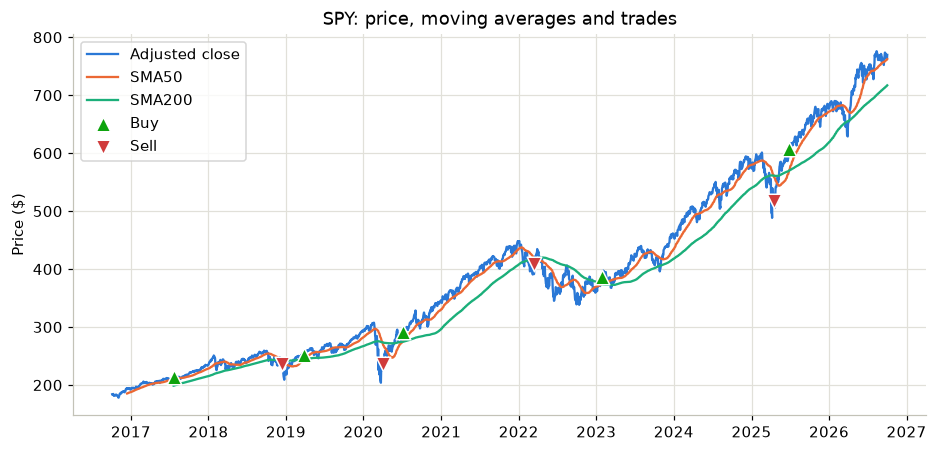

In [30]:
# Price, the two averages and the buy / sell markers
buys = trades[trades["type"] == "BUY"]
sells = trades[trades["type"] == "SELL"]

fig, ax = plt.subplots()
ax.plot(data.index, data["price"], color=BLUE, linewidth=1.5, label="Adjusted close")
ax.plot(data.index, data["sma_short"], color=ORANGE, linewidth=1.5, label=f"SMA{config.SMA_SHORT}")
ax.plot(data.index, data["sma_long"], color=AQUA, linewidth=1.5, label=f"SMA{config.SMA_LONG}")
ax.scatter(buys["date"], buys["price"], marker="^", s=90, color=GREEN, edgecolor="white", zorder=3, label="Buy")
ax.scatter(sells["date"], sells["price"], marker="v", s=90, color=RED, edgecolor="white", zorder=3, label="Sell")
ax.set_title(f"{symbol}: price, moving averages and trades")
ax.set_ylabel("Price ($)")
ax.legend()
plt.show()

### 5.1 Signal label

`recommendation` turns the last two signal values into a simple label: `BUY` (the signal just turned on), `HOLD` (it was already on), `SELL` (it just turned off) or `WAIT` (it was already off, so stay in cash). The label only repeats what the SMA rule says. **It is not investment advice.**

In [31]:
show_code(backtest.recommendation)

```python
def recommendation(signal):
    """Returns what the SMA rule says after the last close: BUY, HOLD, SELL or WAIT."""
    today = signal.iloc[-1]
    yesterday = signal.iloc[-2]
    if today == 1:
        return "BUY" if yesterday == 0 else "HOLD"  # signal just turned on -> BUY, already on -> HOLD
    return "SELL" if yesterday == 1 else "WAIT"     # signal just turned off -> SELL, already off -> WAIT

```

In [32]:
print(f"{symbol}: signal after the last close ->", backtest.recommendation(data["signal"]))

SPY: signal after the last close -> HOLD


## 6. Backtest: portfolio value and metrics

`equity_curve` computes the value of a $10,000 portfolio day by day for a position series (1 = in the position, 0 = cash). A 0.1% commission is paid on every buy and sell.

Buy & Hold goes through the same function: its "signal" is 1 every day. So it buys at the first day's close, pays one commission and holds until the end.

In [33]:
show_code(backtest.equity_curve)

```python
def equity_curve(price, position):
    """Computes the portfolio value for a position series (1 = in the position, 0 = cash)."""
    daily_return = price.pct_change().fillna(0)
    trade = position.diff().abs().fillna(0)  # 1 on the day after a buy or a sell, else 0
    # In the position we earn the day's return. The trade itself was made at the
    # previous day's close; we take its commission on the day after the trade.
    growth = (1 + position * daily_return) * (1 - trade * config.COMMISSION)
    return config.INITIAL_CAPITAL * growth.cumprod()

```

In [34]:
# Portfolio values for the strategy and for Buy & Hold
hold = pd.Series(1, index=data.index).shift(1).fillna(0)
equity = pd.DataFrame({
    "strategy": backtest.equity_curve(data["price"], data["position"]),
    "buy_hold": backtest.equity_curve(data["price"], hold),
})
display(equity.head(3), equity.tail(3))

,strategy,buy_hold
date,,
2016-10-05,"10,000.00","10,000.00"
2016-10-06,"10,000.00","9,996.95"
2016-10-07,"10,000.00","9,962.66"


,strategy,buy_hold
date,,
2026-09-30,"24,115.08","41,372.77"
2026-10-01,"24,158.08","41,446.55"
2026-10-02,"24,336.74","41,753.07"


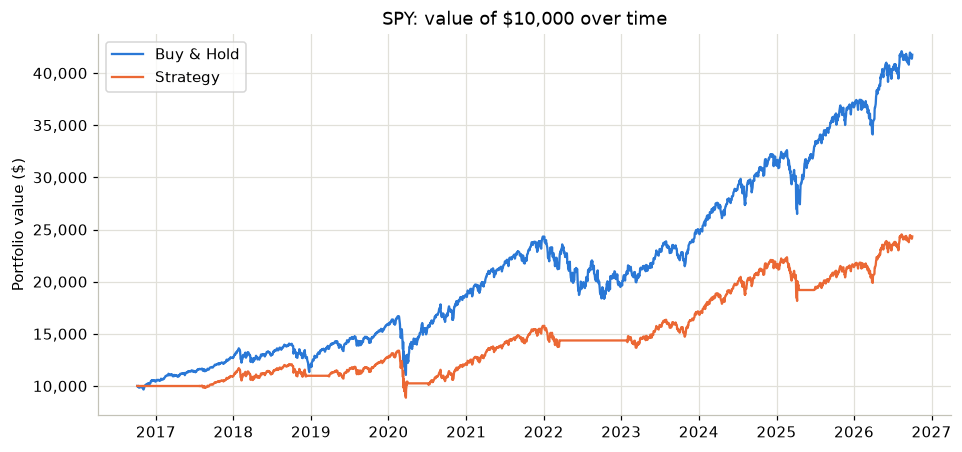

In [35]:
fig, ax = plt.subplots()
ax.plot(equity.index, equity["buy_hold"], color=BLUE, linewidth=1.5, label="Buy & Hold")
ax.plot(equity.index, equity["strategy"], color=ORANGE, linewidth=1.5, label="Strategy")
ax.set_title(f"{symbol}: value of $10,000 over time")
ax.set_ylabel("Portfolio value ($)")
ax.yaxis.set_major_formatter("{x:,.0f}")  # thousands separator on the axis
ax.legend()
plt.show()

The metrics are computed from the portfolio value series:

- **Total return:** final value / starting capital − 1
- **CAGR:** compound annual growth rate
- **Volatility:** standard deviation of the daily returns × √252
- **Sharpe ratio:** yearly average return / yearly volatility (risk-free rate 0)
- **Max drawdown:** the largest fall of the portfolio from its highest value so far

In [36]:
show_code(backtest.compute_metrics)

```python
def compute_metrics(equity, trades):
    """Computes the performance metrics from a portfolio value series."""
    daily_return = equity.pct_change().dropna()
    years = (equity.index[-1] - equity.index[0]).days / 365.25
    total_return = equity.iloc[-1] / config.INITIAL_CAPITAL - 1
    cagr = (1 + total_return) ** (1 / years) - 1  # compound annual growth rate
    volatility = daily_return.std() * np.sqrt(config.TRADING_DAYS)
    # Sharpe ratio (risk-free rate 0): yearly average return / yearly volatility.
    # If the portfolio never entered a position the volatility is 0; then we write 0.
    sharpe = 0.0
    if volatility > 0:
        sharpe = daily_return.mean() * config.TRADING_DAYS / volatility
    drawdown = equity / equity.cummax() - 1  # fall from the highest value so far

    return {
        "final_value": round(float(equity.iloc[-1]), 2),
        "profit": round(float(equity.iloc[-1] - config.INITIAL_CAPITAL), 2),
        "total_return_pct": round(float(total_return * 100), 2),
        "cagr_pct": round(float(cagr * 100), 2),
        "volatility_pct": round(float(volatility * 100), 2),
        "sharpe": round(float(sharpe), 2),
        "max_drawdown_pct": round(float(drawdown.min() * 100), 2),
        "trades": trades,
    }

```

In [37]:
# One row per portfolio, one column per metric
metrics = pd.DataFrame(
    [
        backtest.compute_metrics(equity["strategy"], trades=len(trades)),
        backtest.compute_metrics(equity["buy_hold"], trades=1),
    ],
    index=["Strategy", "Buy & Hold"],
)
metrics

,final_value,profit,total_return_pct,cagr_pct,volatility_pct,sharpe,max_drawdown_pct,trades
Strategy,"24,336.74","14,336.74",143.37,9.31,15.10,0.67,-33.72,9
Buy & Hold,"41,753.07","31,753.07",317.53,15.38,17.95,0.89,-33.72,1


## 7. All symbols

`analyze` runs all the steps above for one symbol and returns the two dictionaries that the dashboard reads: the summary (metrics, trailing returns, signal label) and the detail (daily series, trades, period returns).

In [38]:
show_code(backtest.analyze)

```python
def analyze(symbol):
    """Runs every calculation for one symbol. Returns the (summary, detail) dictionaries."""
    data = add_signals(load_clean(symbol))
    price = data["price"]

    # Buy & Hold: the signal is 1 every day. It goes through the same rule as the
    # strategy, so it buys at the first day's close and pays commission for that one trade.
    hold = pd.Series(1, index=price.index).shift(1).fillna(0)
    data["strategy"] = equity_curve(price, data["position"])
    data["buy_hold"] = equity_curve(price, hold)

    signals = list_trades(data)
    returns = {
        name: to_points(period_returns(price, freq), date_format)
        for name, (freq, date_format) in PERIODS.items()
    }
    signal_changes = data.index[data["signal"].diff().abs() == 1]  # days when the signal changed

    detail = {
        "symbol": symbol,
        "daily": to_records(data[["price", "sma_short", "sma_long", "strategy", "buy_hold"]]),
        "signals": signals,
        "returns": returns,
        "strategy_yearly": to_points(period_returns(data["strategy"], "YE"), "%Y"),
    }
    summary = {
        "symbol": symbol,
        "name": config.SYMBOLS[symbol]["name"],
        "group": config.SYMBOLS[symbol]["group"],
        "start": price.index[0].strftime("%Y-%m-%d"),
        "end": price.index[-1].strftime("%Y-%m-%d"),
        "rows": len(price),
        "last_price": round(float(price.iloc[-1]), 2),
        "recommendation": recommendation(data["signal"]),
        # the day the signal last changed (the first day if it never changed)
        "signal_since": (signal_changes[-1] if len(signal_changes) else price.index[0]).strftime("%Y-%m-%d"),
        "trailing": trailing_returns(price),
        "strategy": compute_metrics(data["strategy"], trades=len(signals)),
        "buy_hold": compute_metrics(data["buy_hold"], trades=1),  # one trade: the first buy
    }
    return summary, detail

```

In [39]:
# Run the analysis for every symbol and keep the results
results = {s: backtest.analyze(s) for s in config.SYMBOLS}

# Comparison table: the strategy and Buy & Hold for every symbol
rows = []
for s, (summary, detail) in results.items():
    strategy, buy_hold = summary["strategy"], summary["buy_hold"]
    rows.append({
        "symbol": s,
        "strategy return (%)": strategy["total_return_pct"],
        "B&H return (%)": buy_hold["total_return_pct"],
        "strategy final value ($)": strategy["final_value"],
        "B&H final value ($)": buy_hold["final_value"],
        "strategy Sharpe": strategy["sharpe"],
        "B&H Sharpe": buy_hold["sharpe"],
        "strategy max drawdown (%)": strategy["max_drawdown_pct"],
        "B&H max drawdown (%)": buy_hold["max_drawdown_pct"],
        "trades": strategy["trades"],
        "winner": "Strategy" if strategy["total_return_pct"] > buy_hold["total_return_pct"] else "Buy & Hold",
        "signal": summary["recommendation"],
    })
comparison = pd.DataFrame(rows).set_index("symbol")
comparison

,strategy return (%),B&H return (%),strategy final value ($),B&H final value ($),strategy Sharpe,B&H Sharpe,strategy max drawdown (%),B&H max drawdown (%),trades,winner,signal
symbol,,,,,,,,,,,
SPY,143.37,317.53,"24,336.74","41,753.07",0.67,0.89,-33.72,-33.72,9,Buy & Hold,HOLD
QQQ,377.52,574.57,"47,751.81","67,456.52",0.91,0.96,-28.56,-35.12,9,Buy & Hold,HOLD
DIA,53.69,238.85,"15,369.10","33,885.28",0.36,0.79,-39.45,-36.70,9,Buy & Hold,HOLD
IWM,0.14,157.15,"10,014.00","25,714.55",0.09,0.53,-50.58,-41.13,15,Buy & Hold,HOLD
EFA,34.42,135.54,"13,442.01","23,554.23",0.29,0.59,-35.35,-34.19,11,Buy & Hold,HOLD
EEM,35.43,122.49,"13,542.87","22,248.82",0.27,0.49,-39.57,-39.82,13,Buy & Hold,HOLD
TUR,-55.41,19.42,"4,459.12","11,941.66",-0.23,0.22,-66.71,-59.25,18,Buy & Hold,WAIT
GLD,135.44,214.42,"23,543.93","31,442.28",0.67,0.78,-27.06,-26.40,14,Buy & Hold,WAIT
SLV,69.40,224.54,"16,939.51","32,454.16",0.33,0.53,-50.97,-52.28,14,Buy & Hold,WAIT


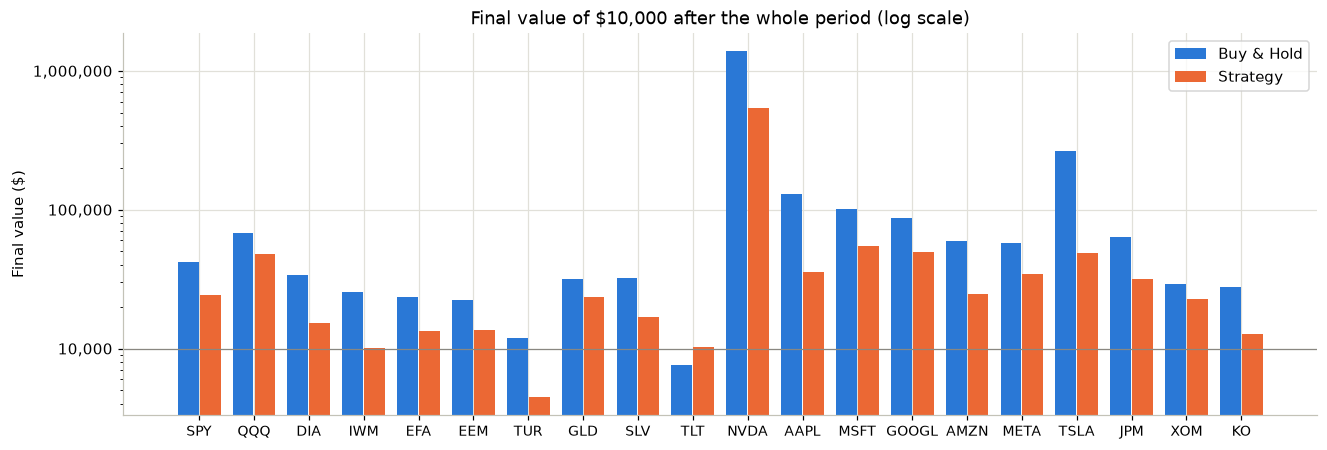

In [40]:
# Final value of $10,000 for every symbol: Buy & Hold next to the strategy.
# The axis is logarithmic because a few companies (for example NVDA) grew far more than the rest.
positions = range(len(comparison))
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.bar([p - 0.2 for p in positions], comparison["B&H final value ($)"], width=0.38, color=BLUE, label="Buy & Hold")
ax.bar([p + 0.2 for p in positions], comparison["strategy final value ($)"], width=0.38, color=ORANGE, label="Strategy")
ax.axhline(config.INITIAL_CAPITAL, color="#898781", linewidth=0.8)  # the starting capital
ax.set_yscale("log")
ax.yaxis.set_major_formatter("{x:,.0f}")
ax.set_xticks(list(positions))
ax.set_xticklabels(comparison.index, fontsize=9)
ax.set_title("Final value of $10,000 after the whole period (log scale)")
ax.set_ylabel("Final value ($)")
ax.legend()
plt.show()

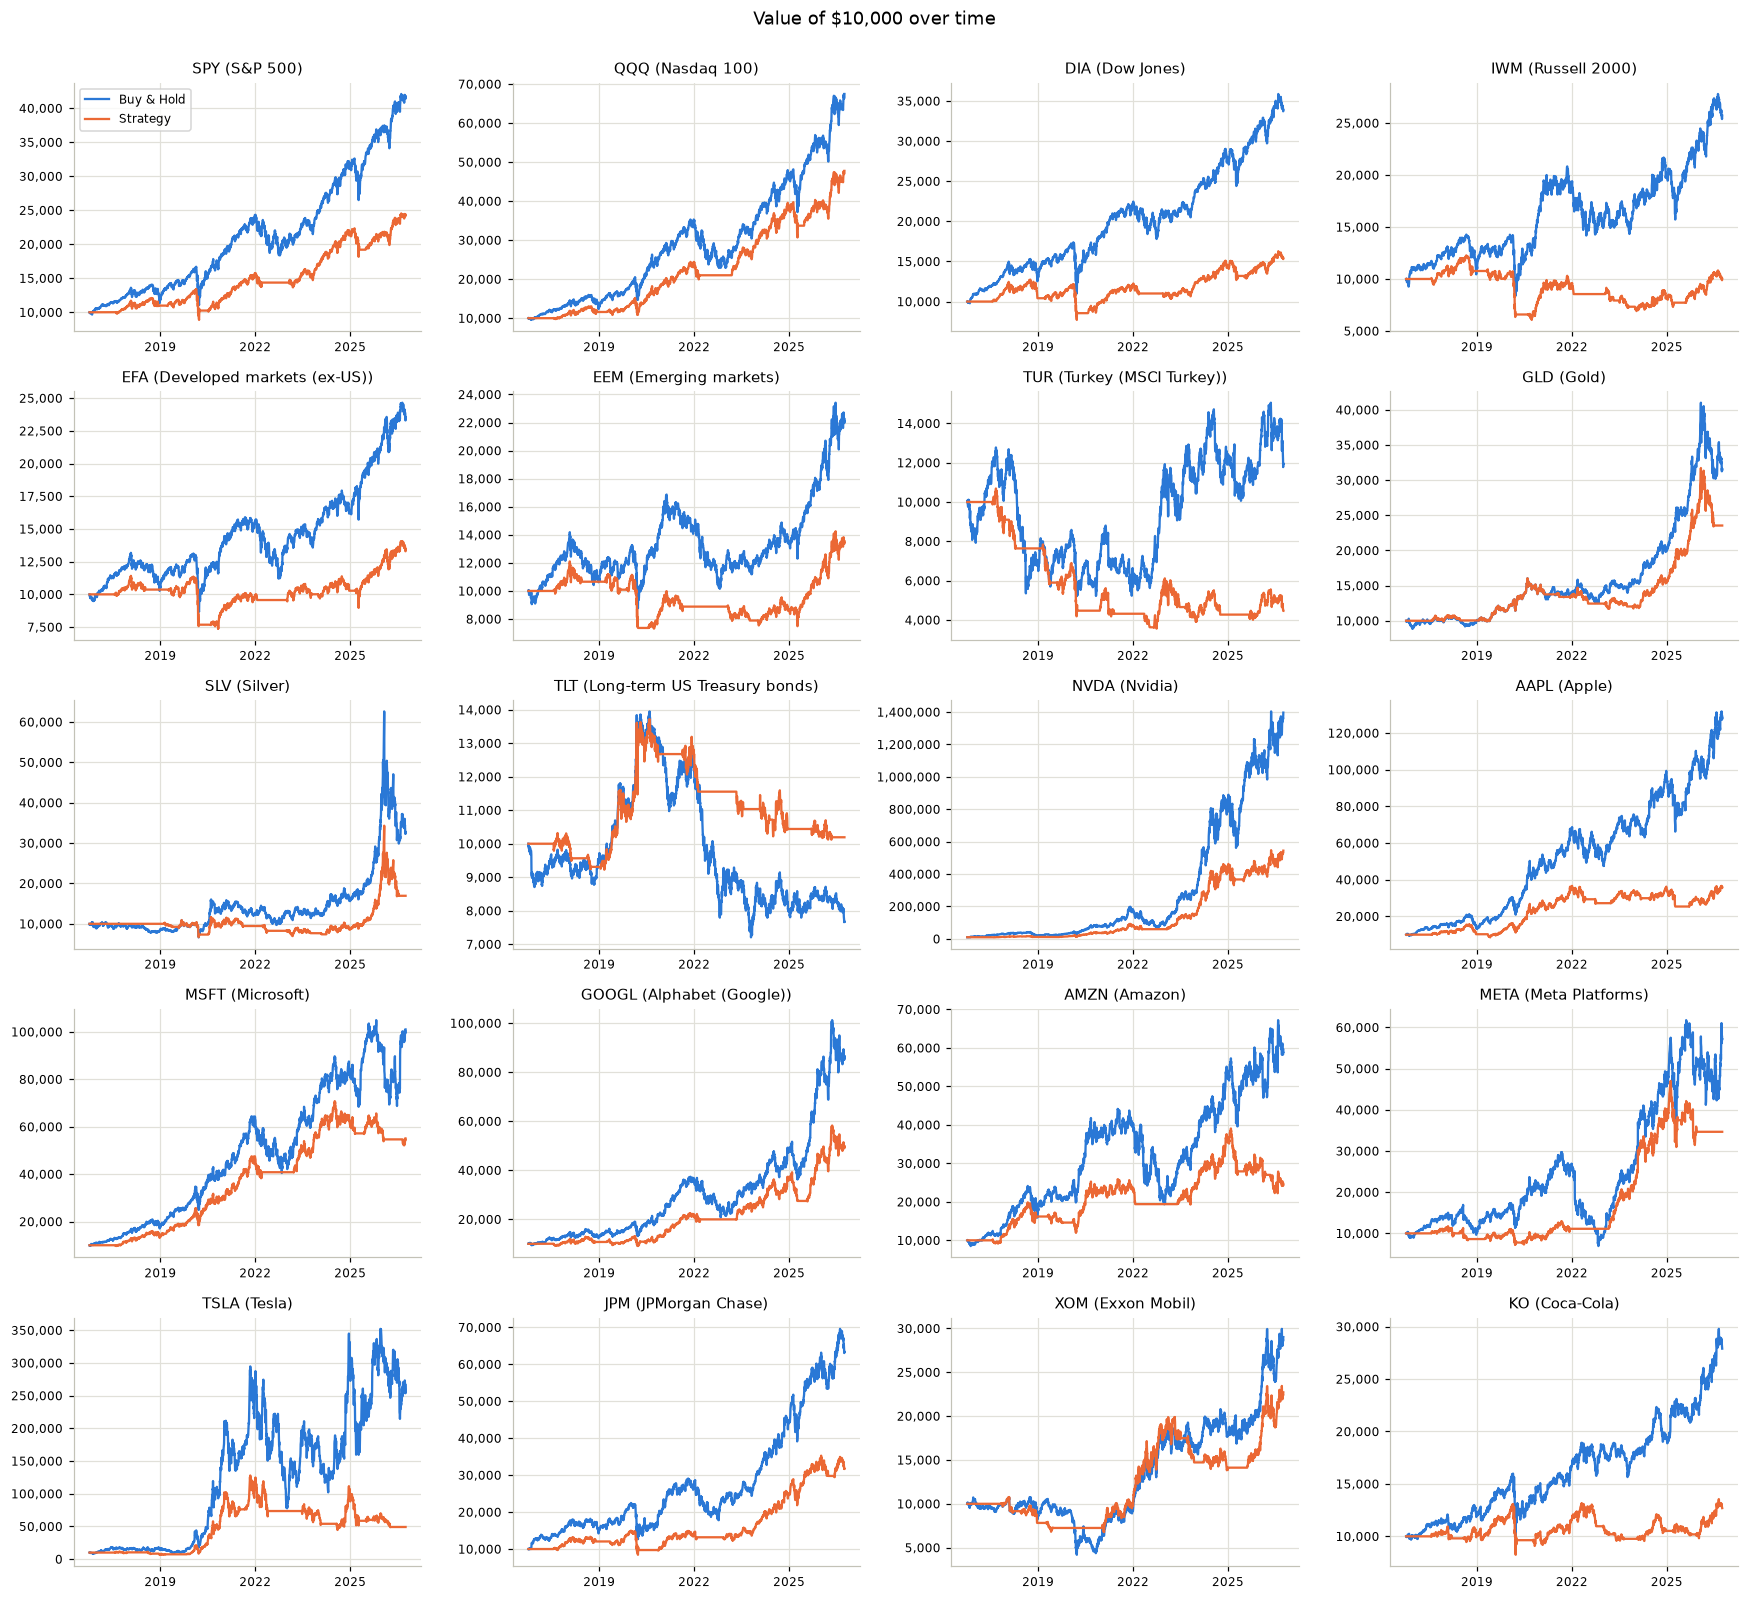

In [41]:
# Portfolio value curves of all symbols (four small charts per row)
rows = (len(results) + 3) // 4
fig, axes = plt.subplots(rows, 4, figsize=(16, 2.9 * rows))
for ax, (s, (summary, detail)) in zip(axes.flat, results.items()):
    daily = pd.DataFrame(detail["daily"])
    daily["date"] = pd.to_datetime(daily["date"])
    ax.plot(daily["date"], daily["buy_hold"], color=BLUE, linewidth=1.5, label="Buy & Hold")
    ax.plot(daily["date"], daily["strategy"], color=ORANGE, linewidth=1.5, label="Strategy")
    ax.set_title(f"{s} ({summary['name']})", fontsize=10)
    ax.yaxis.set_major_formatter("{x:,.0f}")
    ax.xaxis.set_major_locator(mdates.YearLocator(3))  # one tick every 3 years so the labels do not overlap
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(labelsize=8)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Value of $10,000 over time", y=1.0)
fig.tight_layout()
plt.show()

## 8. Sanity checks

A few simple checks before we trust the results:

In [42]:
for s, (summary, detail) in results.items():
    first_day = detail["daily"][0]
    print(
        f"{s}: {summary['rows']} rows ({summary['start']} to {summary['end']}), "
        f"portfolio value on the first day: strategy ${first_day['strategy']:,.0f}, Buy & Hold ${first_day['buy_hold']:,.0f}"
    )

    # 1) Row count: 10 years x about 252 trading days = about 2500
    assert 2400 < summary["rows"] < 2600
    # 2) On the first day the portfolio value must equal the starting capital
    assert first_day["strategy"] == first_day["buy_hold"] == config.INITIAL_CAPITAL

spy = results["SPY"][0]["buy_hold"]
print(f"\nSPY Buy & Hold: total return {spy['total_return_pct']}%, compound annual growth {spy['cagr_pct']}%")

SPY: 2512 rows (2016-10-05 to 2026-10-02), portfolio value on the first day: strategy $10,000, Buy & Hold $10,000
QQQ: 2512 rows (2016-10-05 to 2026-10-02), portfolio value on the first day: strategy $10,000, Buy & Hold $10,000
DIA: 2512 rows (2016-10-05 to 2026-10-02), portfolio value on the first day: strategy $10,000, Buy & Hold $10,000
IWM: 2512 rows (2016-10-05 to 2026-10-02), portfolio value on the first day: strategy $10,000, Buy & Hold $10,000
EFA: 2512 rows (2016-10-05 to 2026-10-02), portfolio value on the first day: strategy $10,000, Buy & Hold $10,000
EEM: 2512 rows (2016-10-05 to 2026-10-02), portfolio value on the first day: strategy $10,000, Buy & Hold $10,000
TUR: 2512 rows (2016-10-05 to 2026-10-02), portfolio value on the first day: strategy $10,000, Buy & Hold $10,000
GLD: 2512 rows (2016-10-05 to 2026-10-02), portfolio value on the first day: strategy $10,000, Buy & Hold $10,000
SLV: 2512 rows (2016-10-05 to 2026-10-02), portfolio value on the first day: strategy $1

**Look-ahead test:** if the strategy does not see the future, changing later prices must not change earlier positions. We raise the price of the last 250 days by 50% and check that the earlier positions stay the same:

In [43]:
original = backtest.load_clean("SPY")
changed = original.copy()
changed.iloc[-250:, changed.columns.get_loc("adj_close")] *= 1.5  # change the price of the last 250 days

before = backtest.add_signals(original)["position"].iloc[:-250]
after = backtest.add_signals(changed)["position"].iloc[:-250]
print("Are the earlier positions the same?", before.equals(after))

Are the earlier positions the same? True


## 9. Comment on the results

This comment is based on the data at the time the notebook was run (October 5, 2016 to October 2, 2026). The numbers change when the data is updated.

**Return:** Buy & Hold had a higher total return than the SMA strategy in 19 of the 20 symbols. The only symbol where the strategy won is TLT, the long-term bond fund.

| Symbol | Strategy | Buy & Hold | Winner |
|---|---|---|---|
| SPY | 143% | 318% | Buy & Hold |
| QQQ | 378% | 575% | Buy & Hold |
| DIA | 54% | 239% | Buy & Hold |
| IWM | 0% | 157% | Buy & Hold |
| EFA | 34% | 136% | Buy & Hold |
| EEM | 35% | 122% | Buy & Hold |
| TUR | -55% | 19% | Buy & Hold |
| GLD | 135% | 214% | Buy & Hold |
| SLV | 69% | 225% | Buy & Hold |
| TLT | 2% | -23% | Strategy |
| NVDA | 5,343% | 13,863% | Buy & Hold |
| AAPL | 258% | 1,189% | Buy & Hold |
| MSFT | 450% | 910% | Buy & Hold |
| GOOGL | 398% | 765% | Buy & Hold |
| AMZN | 147% | 495% | Buy & Hold |
| META | 247% | 472% | Buy & Hold |
| TSLA | 391% | 2,564% | Buy & Hold |
| JPM | 218% | 533% | Buy & Hold |
| XOM | 127% | 190% | Buy & Hold |
| KO | 27% | 179% | Buy & Hold |

**Why?**

- **Delay.** Moving averages follow the price with a delay: the strategy sells after a fall and buys back after the recovery has started. For example, in SPY the strategy sold at $235.74 on March 31, 2020 (the low was on March 23) and bought back at $291.25 on July 6, 2020 (adjusted prices). It missed a rise of about 24%.
- **Choppy markets.** When the price changes direction often, the strategy buys high and sells low. In TUR it made 18 trades, and in 7 of its 9 buy-sell rounds it sold below the buy price: Buy & Hold gained 19% while the strategy lost 55%. In IWM the strategy ended the 10 years where it started, while Buy & Hold gained 157%.
- **The first 200 days.** The strategy stays in cash until SMA200 exists. SPY rose about 16% in that time; Buy & Hold earned this, the strategy did not.
- **Long, strong rises.** The gap is largest in the fastest growing companies. With Buy & Hold, $10,000 in NVDA became about $1,396,000; with the strategy it became about $544,000. In TSLA the numbers are about $266,000 and $49,000. Every time the strategy steps out during a long rise, it gives up part of the gain.
- **Where the strategy helped: a long fall.** TLT lost 31% in 2022. The strategy sold on February 15, 2022, stayed in cash for the rest of the year and finished that year at -9%. After 10 years Buy & Hold lost 23%, while the strategy was about flat (2%).

**Risk:** The strategy is in cash part of the time, so its yearly volatility is lower in all 20 symbols (for example 15.10% against 17.95% in SPY). Even so, the Sharpe ratio is better for Buy & Hold in 19 symbols; TLT is again the exception. The worst loss (maximum drawdown) was clearly smaller with the strategy in 9 symbols, mostly the more volatile ones: META (-38.27% against -76.74%), NVDA (-37.55% against -66.34%), XOM (-37.08% against -61.01%). It was clearly larger in 3 (IWM, TUR, AAPL) and about the same in the rest. Here "clearly" means a difference of more than 5 percentage points.

**Conclusion:** In this period and with these settings (50/200 days, 0.1% commission) the simple SMA crossover strategy earned less than Buy & Hold in rising markets. What it offered was lower risk: lower volatility in every symbol and a smaller worst loss in many volatile ones. It only won on return in an asset that fell for a long time (TLT). The result depends on the period, the settings and the assumptions; in another period it may look different.

## 10. Dashboard

This notebook shows the calculations step by step. The same steps also run with one command:

```
python run_all.py
```

This command downloads the data, cleans it, runs the backtest and writes the results as JSON files into `public/data/`. The web page (dashboard) only reads these JSON files.

*This project is homework for a course. It is not investment advice.*